# 2026-08-04 Initial Check: rSFMS distributions by infall stage

This notebook compares the resolved star-forming main sequence (rSFMS) for the
full selected MAUVE sample and the three infall stages from
`mauve_master_wiki_newclass.fits`. After the combined rSFMS plot, two
equal-galaxy weighted, area-normalized histograms compare the shapes of the
selected spaxel distributions in log stellar-mass surface density and log SFR
surface density.


## Setup and equal-galaxy weighting

The analysis discovers current products below `v3tk_v7.6.8` and selects finite
HII-region SFR and stellar-mass pixels with EW(Halpha) > 6 Angstrom and
intrinsic Halpha dispersion < 45 km/s. `NGC4567_8` inherits an infall class only
when both component galaxies have the same class.

All fitted relations, binned means, contours, and distribution histograms use
**equal total weight per contributing galaxy**. Within a particular selection
(for example, one infall stage, one stellar-mass bin, or one displayed
histogram range), let galaxy $g$ contribute $N_g$ plotting spaxels. Every one
of those spaxels receives weight

$$w_{g,i}=1/N_g.$$

The weights are recalculated after applying that particular selection. Thus a
galaxy with 10,000 selected spaxels and one with 1,000 selected spaxels each
has total weight 1; within either galaxy, its selected spaxels still contribute
equally. Histogram curves additionally use `density=True`, so each curve has
unit area. Consequently, a stage histogram is the equally weighted average of
the contributing galaxies' spaxel distributions, rather than the distribution
of all spaxels pooled with large galaxies dominating. Scatter points remain
unweighted visualizations of the selected spaxels.


In [1]:
# Current further-project products used by the post-peak rSFMS analysis.
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 32
Science-ready current further galaxies: 32
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


,Fit,Method,alpha,beta,N_spaxels,N_galaxies,RMSE,R_squared
0,Pessa+21 (published),Published,1.050,-10.630,--,--,--,--
1,MAUVE all infall stages,Equal-galaxy WLS,0.890,-9.287,"2,800,266",32,0.457,0.526
2,MAUVE pre-peak,Equal-galaxy WLS,0.993,-9.977,"1,976,571",10,0.441,0.536


Selected full-sample HII spaxels (EW(Ha)>6 A, intrinsic sigma<45 km/s): 2,800,266


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_14069/1142637665.py:428: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


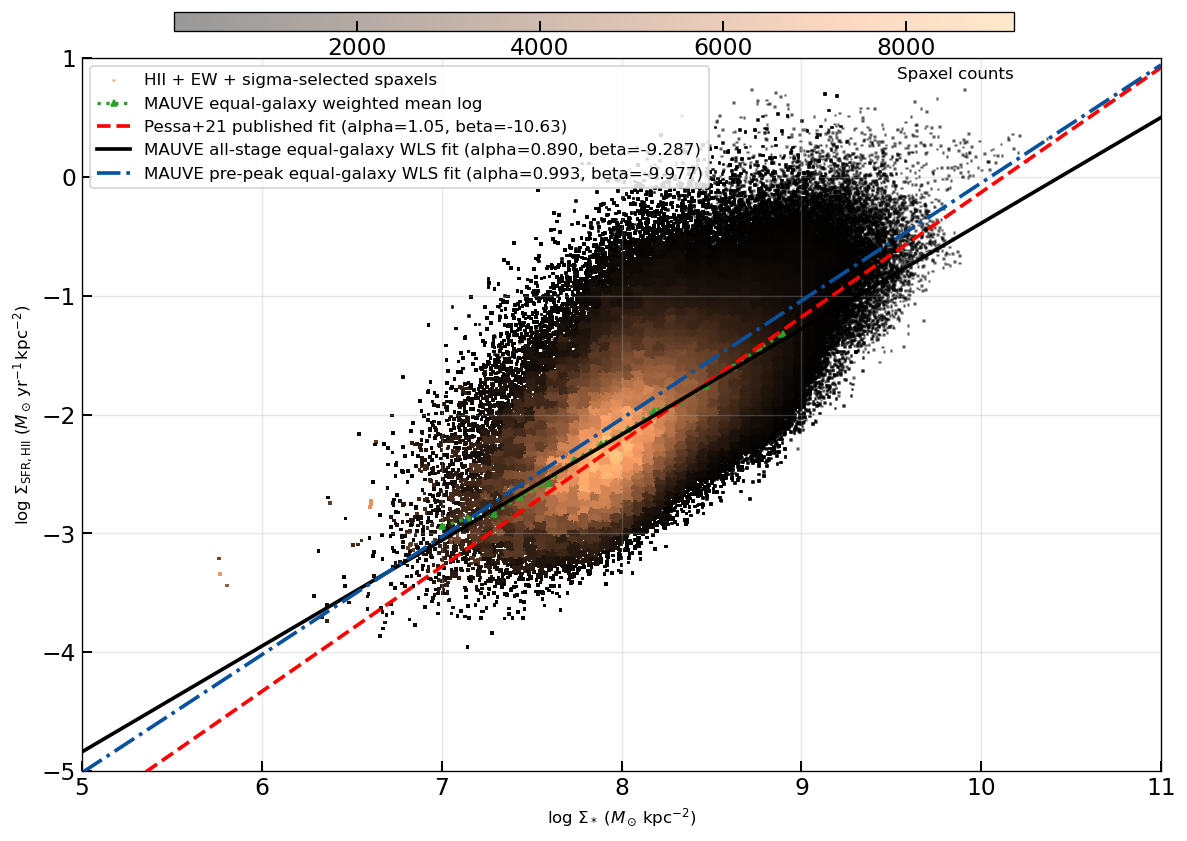

In [4]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS with consistent HII + EW + sigma selection
# Current full further sample, independent of infall stage
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0


def load_selected_rsfms_maps(galaxy):
    """Load and align the four maps needed by the shared rSFMS selection."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy)

    with fits.open(spatial_path) as hdul:
        log_sigma_m = np.asarray(
            hdul["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )
    with fits.open(gas_path) as hdul:
        log_sigma_sfr = np.asarray(
            hdul["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float
        )
        halpha_sigma_obs = np.asarray(hdul["HA6562_SIGMA"].data, dtype=float)
        halpha_sigma_corr = np.asarray(
            hdul["HA6562_SIGMA_CORR"].data, dtype=float
        )
    with fits.open(ew_path) as hdul:
        ew_ha = np.asarray(hdul[EW_HDU].data, dtype=float)

    target_shape = log_sigma_sfr.shape
    log_sigma_m = align_map_to_shape(
        log_sigma_m, target_shape, label=f"{galaxy} stellar mass"
    )
    ew_ha = align_map_to_shape(
        ew_ha, target_shape, label=f"{galaxy} {EW_HDU}"
    )
    halpha_sigma_obs = align_map_to_shape(
        halpha_sigma_obs, target_shape, label=f"{galaxy} HA6562_SIGMA"
    )
    halpha_sigma_corr = align_map_to_shape(
        halpha_sigma_corr, target_shape, label=f"{galaxy} HA6562_SIGMA_CORR"
    )

    sigma2_intrinsic = halpha_sigma_obs**2 - halpha_sigma_corr**2
    halpha_sigma = np.full(target_shape, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    halpha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma


def selected_rsfms_mask(log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma):
    """Select HII spaxels with EW(Halpha)>6 A and intrinsic sigma<45 km/s."""
    return (
        np.isfinite(log_sigma_m)
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
        & np.isfinite(halpha_sigma)
        & (halpha_sigma < HALPHA_SIGMA_MAX)
    )


def equal_galaxy_spaxel_weights(galaxy_ids):
    """Give every represented galaxy total weight one in the current selection."""
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    if galaxy_ids.ndim != 1 or galaxy_ids.size == 0:
        raise ValueError("galaxy_ids must be a non-empty one-dimensional array")
    _, inverse, counts = np.unique(galaxy_ids, return_inverse=True, return_counts=True)
    return 1.0 / counts[inverse]


def weighted_quantile(values, quantiles, weights):
    """Return weighted quantiles using centered cumulative weights."""
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = (np.cumsum(weights) - 0.5 * weights) / np.sum(weights)
    return np.interp(quantiles, cumulative, values)


def binned_rsfms_mean_trend(x, y, galaxy_ids, *, bin_width, min_pixels):
    """Compute equal-galaxy weighted means in central-95% mass bins."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(x) & np.isfinite(y) & (galaxy_ids != "")
    x = x[finite]
    y = y[finite]
    galaxy_ids = galaxy_ids[finite]
    global_weights = equal_galaxy_spaxel_weights(galaxy_ids)
    trend_lo, trend_hi = weighted_quantile(
        x, [0.025, 0.975], global_weights
    )
    central = (x >= trend_lo) & (x <= trend_hi)
    x_data = x[central]
    y_data = y[central]
    galaxy_data = galaxy_ids[central]

    edges = np.arange(trend_lo, trend_hi, bin_width)
    if edges.size == 0:
        edges = np.asarray([trend_lo])
    if edges[-1] < trend_hi:
        edges = np.append(edges, trend_hi)

    trend_x = []
    mean_log = []
    counts = []
    last_bin = len(edges) - 2
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if index == last_bin:
            in_bin = (x_data >= left) & (x_data <= right)
        else:
            in_bin = (x_data >= left) & (x_data < right)
        count = int(np.count_nonzero(in_bin))
        counts.append(count)
        if count < min_pixels:
            trend_x.append(0.5 * (left + right))
            mean_log.append(np.nan)
            continue

        x_bin = x_data[in_bin]
        y_bin = y_data[in_bin]
        galaxy_bin = galaxy_data[in_bin]
        bin_weights = equal_galaxy_spaxel_weights(galaxy_bin)
        trend_x.append(np.average(x_bin, weights=bin_weights))
        mean_log.append(np.average(y_bin, weights=bin_weights))

    return (
        np.asarray(trend_x),
        np.asarray(mean_log),
        np.asarray(counts, dtype=int),
        (trend_lo, trend_hi),
    )


def equal_galaxy_rsfms_fit(x, y, galaxy_ids):
    """Fit log Sigma_SFR versus log Sigma_* with equal galaxy total weights."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(x) & np.isfinite(y) & (galaxy_ids != "")
    x_fit = x[finite]
    y_fit = y[finite]
    galaxy_fit = galaxy_ids[finite]
    if x_fit.size < 2:
        raise ValueError("At least two finite spaxels are required for the fit")

    weights = equal_galaxy_spaxel_weights(galaxy_fit)
    design = np.column_stack((x_fit, np.ones_like(x_fit)))
    sqrt_weights = np.sqrt(weights)
    alpha, beta = np.linalg.lstsq(
        design * sqrt_weights[:, None], y_fit * sqrt_weights, rcond=None
    )[0]
    residuals = y_fit - (alpha * x_fit + beta)
    weighted_y_mean = np.average(y_fit, weights=weights)
    ss_res = np.sum(weights * residuals**2)
    ss_tot = np.sum(weights * (y_fit - weighted_y_mean)**2)
    return {
        "alpha": float(alpha),
        "beta": float(beta),
        "n_spaxels": int(x_fit.size),
        "n_galaxies": int(np.unique(galaxy_fit).size),
        "rmse": float(np.sqrt(np.average(residuals**2, weights=weights))),
        "r_squared": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }


def equal_galaxy_histogram_data(values, galaxy_ids, bins):
    """Return plotted values and weights after recalculating N_g in bin range."""
    values = np.asarray(values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    plotted = (
        np.isfinite(values)
        & (galaxy_ids != "")
        & (values >= bins[0])
        & (values <= bins[-1])
    )
    values = values[plotted]
    galaxy_ids = galaxy_ids[plotted]
    if values.size == 0:
        return values, np.asarray([], dtype=float), galaxy_ids
    return values, equal_galaxy_spaxel_weights(galaxy_ids), galaxy_ids


# Discover every current further galaxy with mass, HII-SFR, and EW maps.
full_sample_galaxies = PRODUCTS.index[
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
].tolist()


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    full_sample_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
full_sample_infall_class = add_combined_infall_classes(full_sample_infall_class)

all_x_full = []
all_y_full = []
all_galaxy_full = []
all_x_infall_stages = []
all_y_infall_stages = []
all_galaxy_infall_stages = []
all_x_pre_peak = []
all_y_pre_peak = []
all_galaxy_pre_peak = []
full_sample_galaxy_counts = {}

for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps

    if np.any(selected):
        x_det = log_sigma_m[selected]
        y_det = log_sigma_sfr[selected]
        all_x_full.extend(x_det.ravel())
        all_y_full.extend(y_det.ravel())
        all_galaxy_full.extend([galaxy] * x_det.size)
        stage = full_sample_infall_class.get(galaxy)
        if stage in (1, 2, 3):
            all_x_infall_stages.extend(x_det.ravel())
            all_y_infall_stages.extend(y_det.ravel())
            all_galaxy_infall_stages.extend([galaxy] * x_det.size)
        if stage == 1:
            all_x_pre_peak.extend(x_det.ravel())
            all_y_pre_peak.extend(y_det.ravel())
            all_galaxy_pre_peak.extend([galaxy] * x_det.size)
        full_sample_galaxy_counts[galaxy] = int(x_det.size)
    else:
        full_sample_galaxy_counts[galaxy] = 0
        print(f"Skipping {galaxy}: no HII+EW+sigma-selected spaxels")

all_x_full = np.asarray(all_x_full, dtype=float)
all_y_full = np.asarray(all_y_full, dtype=float)
all_galaxy_full = np.asarray(all_galaxy_full, dtype=str)
if all_x_full.size == 0:
    raise RuntimeError("No valid HII+EW+sigma rSFMS data found.")


all_x_infall_stages = np.asarray(all_x_infall_stages, dtype=float)
all_y_infall_stages = np.asarray(all_y_infall_stages, dtype=float)
all_galaxy_infall_stages = np.asarray(all_galaxy_infall_stages, dtype=str)
all_x_pre_peak = np.asarray(all_x_pre_peak, dtype=float)
all_y_pre_peak = np.asarray(all_y_pre_peak, dtype=float)
all_galaxy_pre_peak = np.asarray(all_galaxy_pre_peak, dtype=str)
if all_x_infall_stages.size == 0:
    raise RuntimeError("No valid class 1-3 spaxels found for the all-stage weighted fit.")
if all_x_pre_peak.size == 0:
    raise RuntimeError("No valid pre-peak spaxels found for the weighted fit.")

mauve_all_fit = equal_galaxy_rsfms_fit(
    all_x_infall_stages, all_y_infall_stages, all_galaxy_infall_stages
)
mauve_pre_peak_fit = equal_galaxy_rsfms_fit(
    all_x_pre_peak, all_y_pre_peak, all_galaxy_pre_peak
)
mauve_all_alpha = mauve_all_fit["alpha"]
mauve_all_intercept = mauve_all_fit["beta"]
mauve_pre_peak_alpha = mauve_pre_peak_fit["alpha"]
mauve_pre_peak_intercept = mauve_pre_peak_fit["beta"]

pessa_alpha_full = 1.05
pessa_intercept_full = -10.63
rsfms_fit_results = pd.DataFrame(
    [
        {
            "Fit": "Pessa+21 (published)",
            "Method": "Published",
            "alpha": pessa_alpha_full,
            "beta": pessa_intercept_full,
            "N_spaxels": "--",
            "N_galaxies": "--",
            "RMSE": np.nan,
            "R_squared": np.nan,
        },
        {
            "Fit": "MAUVE all infall stages",
            "Method": "Equal-galaxy WLS",
            "alpha": mauve_all_alpha,
            "beta": mauve_all_intercept,
            "N_spaxels": f"{mauve_all_fit['n_spaxels']:,}",
            "N_galaxies": mauve_all_fit["n_galaxies"],
            "RMSE": mauve_all_fit["rmse"],
            "R_squared": mauve_all_fit["r_squared"],
        },
        {
            "Fit": "MAUVE pre-peak",
            "Method": "Equal-galaxy WLS",
            "alpha": mauve_pre_peak_alpha,
            "beta": mauve_pre_peak_intercept,
            "N_spaxels": f"{mauve_pre_peak_fit['n_spaxels']:,}",
            "N_galaxies": mauve_pre_peak_fit["n_galaxies"],
            "RMSE": mauve_pre_peak_fit["rmse"],
            "R_squared": mauve_pre_peak_fit["r_squared"],
        },
    ]
)
display(
    rsfms_fit_results.style.format(
        {"alpha": "{:.3f}", "beta": "{:.3f}", "RMSE": "{:.3f}", "R_squared": "{:.3f}"},
        na_rep="--",
    )
)


print(
    "Selected full-sample HII spaxels "
    f"(EW(Ha)>{EW_MIN:g} A, intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s): "
    f"{all_y_full.size:,}"
)

fig, ax_combined = plt.subplots(figsize=(10, 8))

# Density-colored scatter of all selected pixels.
H, xedges, yedges = np.histogram2d(
    all_x_full,
    all_y_full,
    bins=100,
    range=[[5, 11], [-5, 1]],
)
x_idx = np.clip(np.digitize(all_x_full, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y_full, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x_full,
    all_y_full,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="HII + EW + sigma-selected spaxels",
    zorder=1,
)

# The mean-log trend uses exact percentile bounds. NaNs preserve gaps where a bin
# contains fewer than 50 selected pixels, preventing unsupported line segments.
(
    trend_x_full,
    mean_log_hii_full,
    trend_counts_full,
    (trend_lo_full, trend_hi_full),
) = binned_rsfms_mean_trend(
    all_x_full,
    all_y_full,
    all_galaxy_full,
    bin_width=0.15,
    min_pixels=50,
)
bin_width = 0.15
min_pixels_per_bin = 50

ax_combined.plot(
    trend_x_full,
    mean_log_hii_full,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE equal-galaxy weighted mean log",
    zorder=7,
)


x_rsfms_fit_full = np.linspace(5, 11, 200)
ax_combined.plot(
    x_rsfms_fit_full,
    pessa_alpha_full * x_rsfms_fit_full + pessa_intercept_full,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 published fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_all_alpha * x_rsfms_fit_full + mauve_all_intercept,
    color="black",
    linestyle="-",
    linewidth=2.2,
    label=(
        f"MAUVE all-stage equal-galaxy WLS fit "
        f"(alpha={mauve_all_alpha:.3f}, beta={mauve_all_intercept:.3f})"
    ),
    zorder=9,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_pre_peak_alpha * x_rsfms_fit_full + mauve_pre_peak_intercept,
    color="#08519C",
    linestyle="-.",
    linewidth=2.2,
    label=(
        f"MAUVE pre-peak equal-galaxy WLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
    zorder=10,
)

ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}}\; "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
)
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(
    loc="upper left", ncol=1, frameon=True, framealpha=0.85
)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")
plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.pdf", bbox_inches="tight")
plt.show()


## Resolved star-forming main sequence by infall stage

The plotted points show all selected HII-region spaxels, but they do not set
the statistical weight. The mean-log curves use 0.15 dex stellar-mass bins and
recompute $N_g$ inside every bin, so each galaxy represented in that bin has
total weight 1. The reference curve is the equal-galaxy weighted pre-peak fit
measured in cell 6 with the same selected-spaxel definition. The stage contours
also use equal-galaxy weights recalculated for the central-95% mass selection.


  IC3392: 13,897 Post-peak selected spaxels
  NGC4064: 3,273 Post-peak selected spaxels
  NGC4189: 96,364 Pre-peak selected spaxels
  NGC4192: 144,333 Pre-peak selected spaxels
  NGC4254: 661,963 Pre-peak selected spaxels
  NGC4293: 471 Post-peak selected spaxels
  NGC4294: 68,833 Pre-peak selected spaxels
  NGC4298: 144,157 Close-to-peak selected spaxels
  NGC4302: 27,304 Close-to-peak selected spaxels
  NGC4321: 454,131 Pre-peak selected spaxels
  NGC4330: 35,688 Close-to-peak selected spaxels
  NGC4351: 30,711 Pre-peak selected spaxels
  NGC4380: 64,097 Post-peak selected spaxels
  NGC4383: 25,212 Pre-peak selected spaxels
  NGC4388: 17,663 Close-to-peak selected spaxels
  NGC4394: 31,915 Post-peak selected spaxels
  NGC4396: 85,378 Pre-peak selected spaxels
  NGC4402: 46,769 Close-to-peak selected spaxels
  NGC4405: 13,569 Post-peak selected spaxels
  NGC4419: 5,763 Post-peak selected spaxels
  NGC4450: 17,186 Post-peak selected spaxels
  NGC4457: 5,604 Post-peak selected spaxels
 

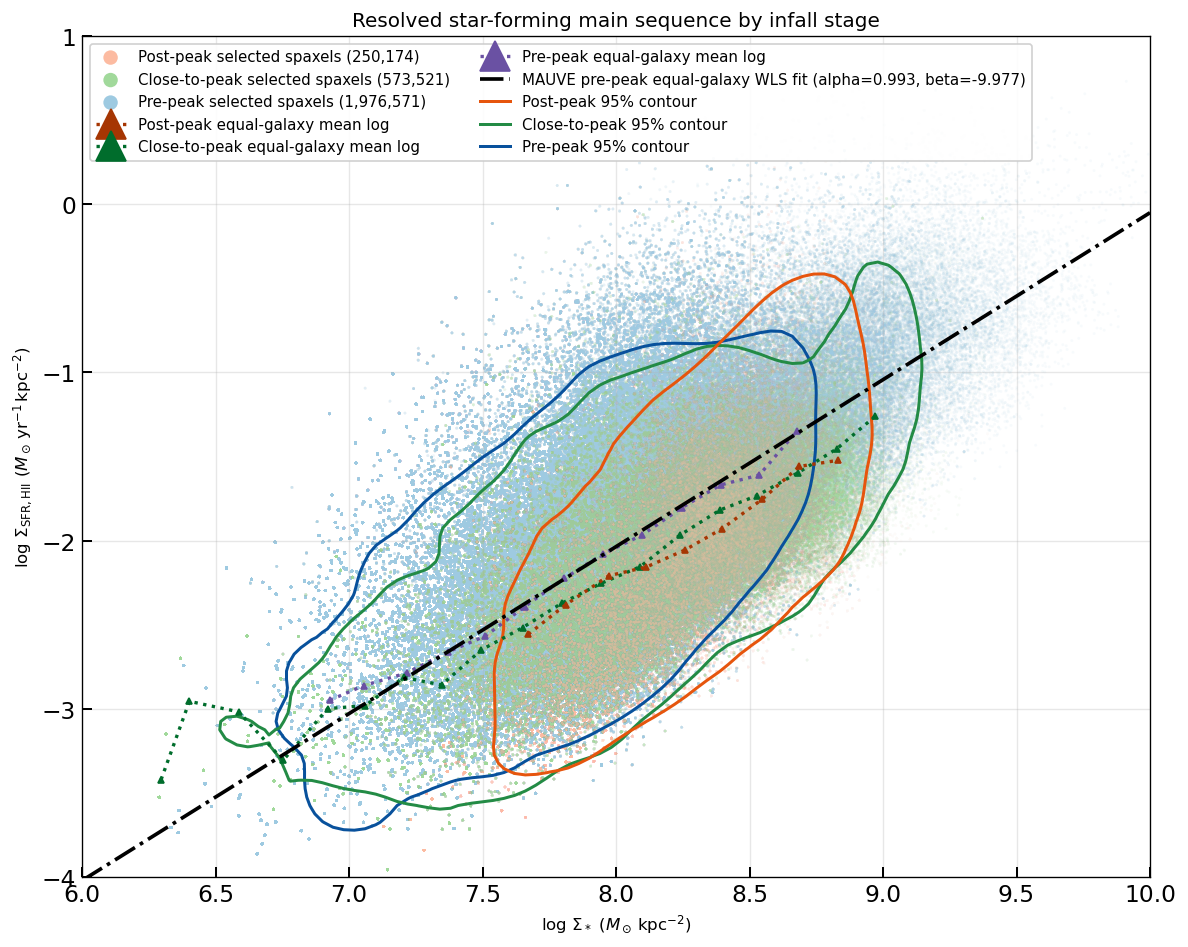


rSFMS sample by infall stage:
  Pre-peak: 1,976,571 spaxels from 10 galaxies
  Close-to-peak: 573,521 spaxels from 8 galaxies
  Post-peak: 250,174 spaxels from 14 galaxies
Selection: HII + EW(Ha)>6 A + intrinsic sigma<45 km/s
Trends: central 95% in stellar mass, 0.15-dex bins, >=50 pixels per bin; equal total weight per galaxy in each bin


In [5]:
# Add pre-peak and close-to-peak samples using the same selection.
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.15
RSFMS_MIN_PIXELS_PER_BIN = 50

RSFMS_STAGE_LABELS = {
    1: "Pre-peak",
    2: "Close-to-peak",
    3: "Post-peak",
}
RSFMS_STAGE_STYLE = {
    1: {
        "scatter": "#9ECAE1",
        "contour": "#08519C",
        "mean_log": "#6A51A3",
        "alpha": 0.08,
        "zorder": 1.0,
    },
    2: {
        "scatter": "#A1D99B",
        "contour": "#238B45",
        "mean_log": "#006D2C",
        "alpha": 0.035,
        "zorder": 2.0,
    },
    3: {
        "scatter": "#FCBBA1",
        "contour": "#E6550D",
        "mean_log": "#A63603",
        "alpha": 0.025,
        "zorder": 3.0,
    },
}
STAGE_CONTOUR_ZORDER = 4.0
STAGE_TREND_ZORDER = 6.0
RSFMS_CONTOUR_BINS = 100
RSFMS_CONTOUR_SMOOTHING = 2.0

stage_log_sigma_m = {stage: [] for stage in (1, 2, 3)}
stage_log_sigma_sfr = {stage: [] for stage in (1, 2, 3)}
stage_spaxel_galaxy = {stage: [] for stage in (1, 2, 3)}
stage_galaxies = {stage: [] for stage in (1, 2, 3)}

print("Collecting selected HII spaxels for all three infall stages...")
for galaxy in full_sample_galaxies:
    stage = full_sample_infall_class.get(galaxy)
    if stage not in (1, 2, 3):
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} {RSFMS_STAGE_LABELS[stage]} selected spaxels")
    if n_spaxels == 0:
        continue
    stage_galaxies[stage].append(galaxy)
    stage_log_sigma_m[stage].extend(log_sigma_m[selected].ravel())
    stage_log_sigma_sfr[stage].extend(log_sigma_sfr[selected].ravel())
    stage_spaxel_galaxy[stage].extend([galaxy] * n_spaxels)

for stage in (1, 2, 3):
    stage_log_sigma_m[stage] = np.asarray(stage_log_sigma_m[stage], dtype=float)
    stage_log_sigma_sfr[stage] = np.asarray(stage_log_sigma_sfr[stage], dtype=float)
    stage_spaxel_galaxy[stage] = np.asarray(stage_spaxel_galaxy[stage], dtype=str)


def plot_stage_95_contour(ax, x, y, galaxy_ids, *, color, zorder):
    """Plot an equal-galaxy weighted 95% contour for the central mass sample."""
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    sample_weights = equal_galaxy_spaxel_weights(galaxy_ids)
    trend_lo, trend_hi = weighted_quantile(
        x, [0.025, 0.975], sample_weights
    )
    central = (x >= trend_lo) & (x <= trend_hi)
    contour_weights = equal_galaxy_spaxel_weights(galaxy_ids[central])
    histogram, xedges, yedges = np.histogram2d(
        x[central],
        y[central],
        bins=RSFMS_CONTOUR_BINS,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
        weights=contour_weights,
    )
    smoothed = gaussian_filter(histogram, sigma=RSFMS_CONTOUR_SMOOTHING)
    ranked = np.sort(smoothed[smoothed > 0].ravel())[::-1]
    if ranked.size == 0:
        return None
    cumulative = np.cumsum(ranked)
    level_index = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    level_95 = ranked[min(level_index, ranked.size - 1)]
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    return ax.contour(
        xcenters,
        ycenters,
        smoothed.T,
        levels=[level_95],
        colors=[color],
        linewidths=1.8,
        linestyles="-",
        zorder=zorder,
    )


fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: pre-peak lowest, close-to-peak next, post-peak highest.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x,
        y,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} selected spaxels ({x.size:,})",
    )

# One 95%-population contour per stage, above scatter and below the mean-log trends.
contour_handles = []
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    plot_stage_95_contour(
        ax,
        x,
        y,
        stage_spaxel_galaxy[stage],
        color=style["contour"],
        zorder=STAGE_CONTOUR_ZORDER + 0.1 * style["zorder"],
    )
    contour_handles.append(
        Line2D(
            [0], [0], color=style["contour"], linewidth=1.8,
            label=f"{RSFMS_STAGE_LABELS[stage]} 95% contour",
        )
    )

# Mean-log curves are above every scatter and contour layer.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    (
        trend_x,
        mean_log,
        trend_counts,
        trend_limits,
    ) = binned_rsfms_mean_trend(
        x,
        y,
        stage_spaxel_galaxy[stage],
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    ax.plot(
        trend_x,
        mean_log,
        color=style["mean_log"],
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=STAGE_TREND_ZORDER + style["zorder"] + 0.1,
        label=f"{RSFMS_STAGE_LABELS[stage]} equal-galaxy mean log",
    )

x_pre_peak_fit = np.linspace(*RSFMS_XRANGE, 200)
y_pre_peak_fit = mauve_pre_peak_alpha * x_pre_peak_fit + mauve_pre_peak_intercept
ax.plot(
    x_pre_peak_fit,
    y_pre_peak_fit,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    zorder=10.0,
    label=(
        f"MAUVE pre-peak equal-galaxy WLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.extend(contour_handles)
labels.extend(handle.get_label() for handle in contour_handles)
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in (1, 2, 3):
    print(
        f"  {RSFMS_STAGE_LABELS[stage]}: "
        f"{stage_log_sigma_m[stage].size:,} spaxels from "
        f"{len(stage_galaxies[stage])} galaxies"
    )
print(f"Selection: HII + EW(Ha)>{EW_MIN:g} A + intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s")
print(
    f"Trends: central 95% in stellar mass, {RSFMS_BIN_WIDTH:g}-dex bins, "
    f">={RSFMS_MIN_PIXELS_PER_BIN} pixels per bin; equal total weight per galaxy in each bin"
)


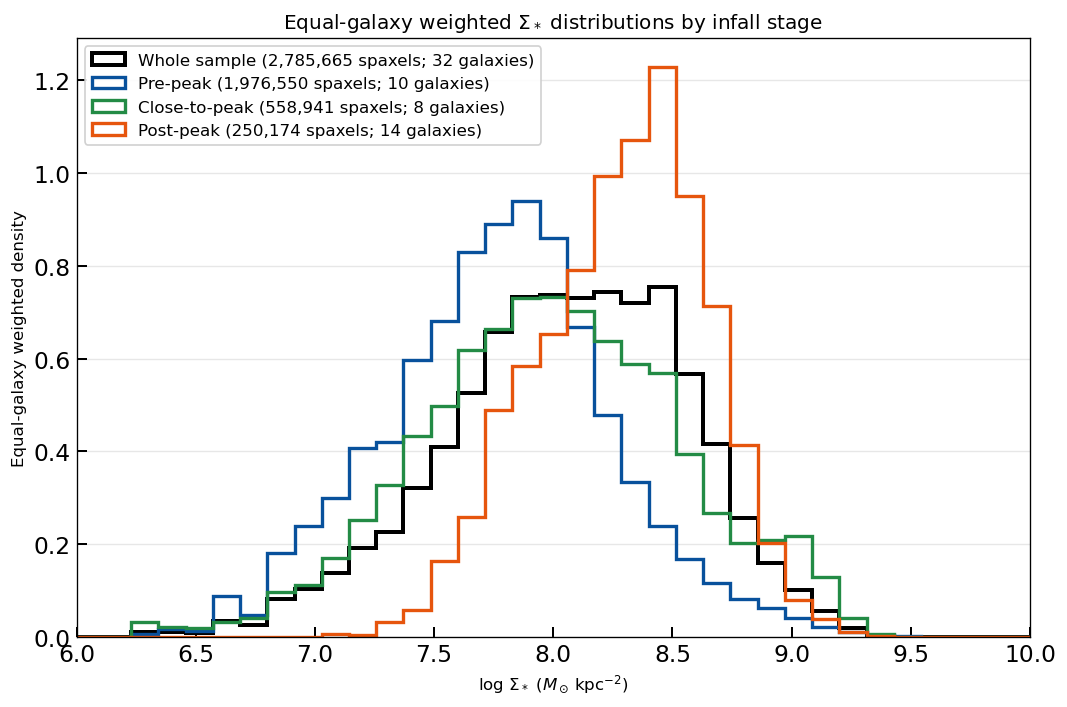

In [6]:
# Equal-galaxy weighted, area-normalized log Sigma_* distributions for the full sample and each infall stage.
HISTOGRAM_BINS = 35
HISTOGRAM_FULL_STYLE = {
    "color": "black",
    "linewidth": 2.4,
    "linestyle": "-",
}

mass_edges = np.linspace(*RSFMS_XRANGE, HISTOGRAM_BINS + 1)

fig, ax = plt.subplots(figsize=(9, 6))
full_mass, full_mass_weights, full_mass_galaxies = equal_galaxy_histogram_data(
    all_x_full, all_galaxy_full, mass_edges
)
ax.hist(
    full_mass,
    bins=mass_edges,
    weights=full_mass_weights,
    density=True,
    histtype="step",
    label=f"Whole sample ({full_mass.size:,} spaxels; {np.unique(full_mass_galaxies).size} galaxies)",
    **HISTOGRAM_FULL_STYLE,
)
for stage in (1, 2, 3):
    values, weights, galaxy_ids = equal_galaxy_histogram_data(
        stage_log_sigma_m[stage], stage_spaxel_galaxy[stage], mass_edges
    )
    ax.hist(
        values,
        bins=mass_edges,
        weights=weights,
        density=True,
        histtype="step",
        color=RSFMS_STAGE_STYLE[stage]["contour"],
        linewidth=2.0,
        label=f"{RSFMS_STAGE_LABELS[stage]} ({values.size:,} spaxels; {np.unique(galaxy_ids).size} galaxies)",
    )

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_XRANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distributions by infall stage",
)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(framealpha=0.9)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_logSigmaStar_histogram_by_infall_stage.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_logSigmaStar_histogram_by_infall_stage.pdf", bbox_inches="tight")
plt.show()


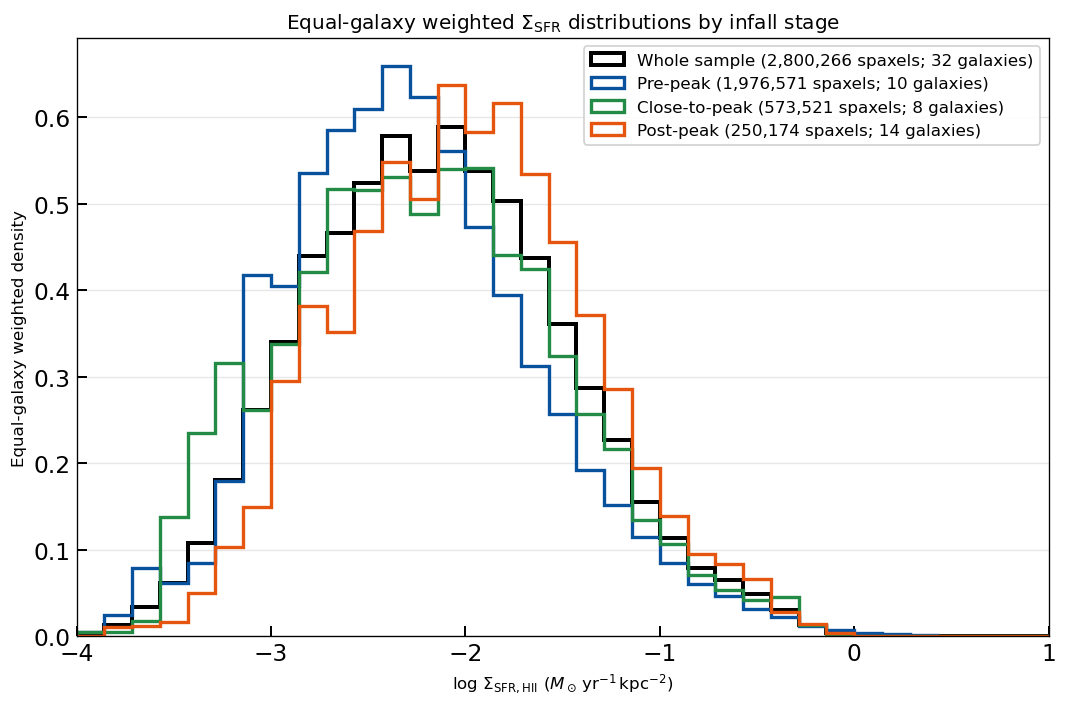

In [7]:
# Equal-galaxy weighted, area-normalized log Sigma_SFR distributions for the full sample and each infall stage.
sfr_edges = np.linspace(*RSFMS_YRANGE, HISTOGRAM_BINS + 1)

fig, ax = plt.subplots(figsize=(9, 6))
full_sfr, full_sfr_weights, full_sfr_galaxies = equal_galaxy_histogram_data(
    all_y_full, all_galaxy_full, sfr_edges
)
ax.hist(
    full_sfr,
    bins=sfr_edges,
    weights=full_sfr_weights,
    density=True,
    histtype="step",
    label=f"Whole sample ({full_sfr.size:,} spaxels; {np.unique(full_sfr_galaxies).size} galaxies)",
    **HISTOGRAM_FULL_STYLE,
)
for stage in (1, 2, 3):
    values, weights, galaxy_ids = equal_galaxy_histogram_data(
        stage_log_sigma_sfr[stage], stage_spaxel_galaxy[stage], sfr_edges
    )
    ax.hist(
        values,
        bins=sfr_edges,
        weights=weights,
        density=True,
        histtype="step",
        color=RSFMS_STAGE_STYLE[stage]["contour"],
        linewidth=2.0,
        label=f"{RSFMS_STAGE_LABELS[stage]} ({values.size:,} spaxels; {np.unique(galaxy_ids).size} galaxies)",
    )

ax.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distributions by infall stage",
)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(framealpha=0.9)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_logSigmaSFR_histogram_by_infall_stage.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_logSigmaSFR_histogram_by_infall_stage.pdf", bbox_inches="tight")
plt.show()


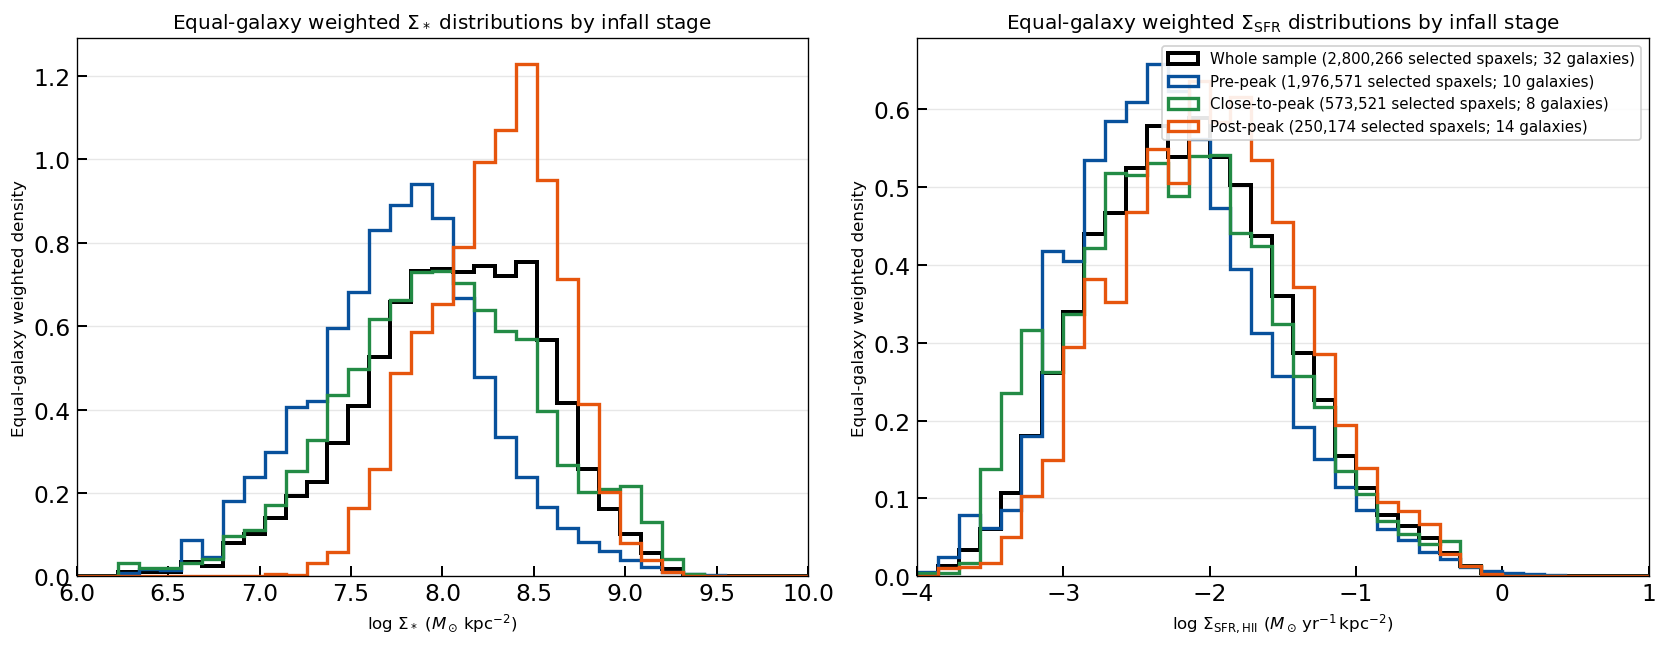

In [8]:
# Side-by-side full-range equal-galaxy weighted mass and SFR distributions.
fig, (ax_mass, ax_sfr) = plt.subplots(1, 2, figsize=(14, 5.5))

full_range_samples = [
    ("Whole sample", all_x_full, all_y_full, all_galaxy_full, HISTOGRAM_FULL_STYLE)
]
for stage in (1, 2, 3):
    full_range_samples.append(
        (
            RSFMS_STAGE_LABELS[stage],
            stage_log_sigma_m[stage],
            stage_log_sigma_sfr[stage],
            stage_spaxel_galaxy[stage],
            {
                "color": RSFMS_STAGE_STYLE[stage]["contour"],
                "linewidth": 2.0,
                "linestyle": "-",
            },
        )
    )

for label, mass_values, sfr_values, galaxy_ids, style in full_range_samples:
    mass_values = np.asarray(mass_values, dtype=float)
    sfr_values = np.asarray(sfr_values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(mass_values) & np.isfinite(sfr_values)
    mass_values = mass_values[finite]
    sfr_values = sfr_values[finite]
    galaxy_ids = galaxy_ids[finite]
    mass_plot, mass_weights, mass_galaxies = equal_galaxy_histogram_data(
        mass_values, galaxy_ids, mass_edges
    )
    sfr_plot, sfr_weights, sfr_galaxies = equal_galaxy_histogram_data(
        sfr_values, galaxy_ids, sfr_edges
    )
    legend_label = (
        f"{label} ({mass_values.size:,} selected spaxels; "
        f"{np.unique(galaxy_ids).size} galaxies)"
    )

    ax_mass.hist(
        mass_plot,
        bins=mass_edges,
        weights=mass_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )
    ax_sfr.hist(
        sfr_plot,
        bins=sfr_edges,
        weights=sfr_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )

ax_mass.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_XRANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distributions by infall stage",
)
ax_sfr.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distributions by infall stage",
)
for axis in (ax_mass, ax_sfr):
    axis.grid(True, axis="y", alpha=0.3)
ax_sfr.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


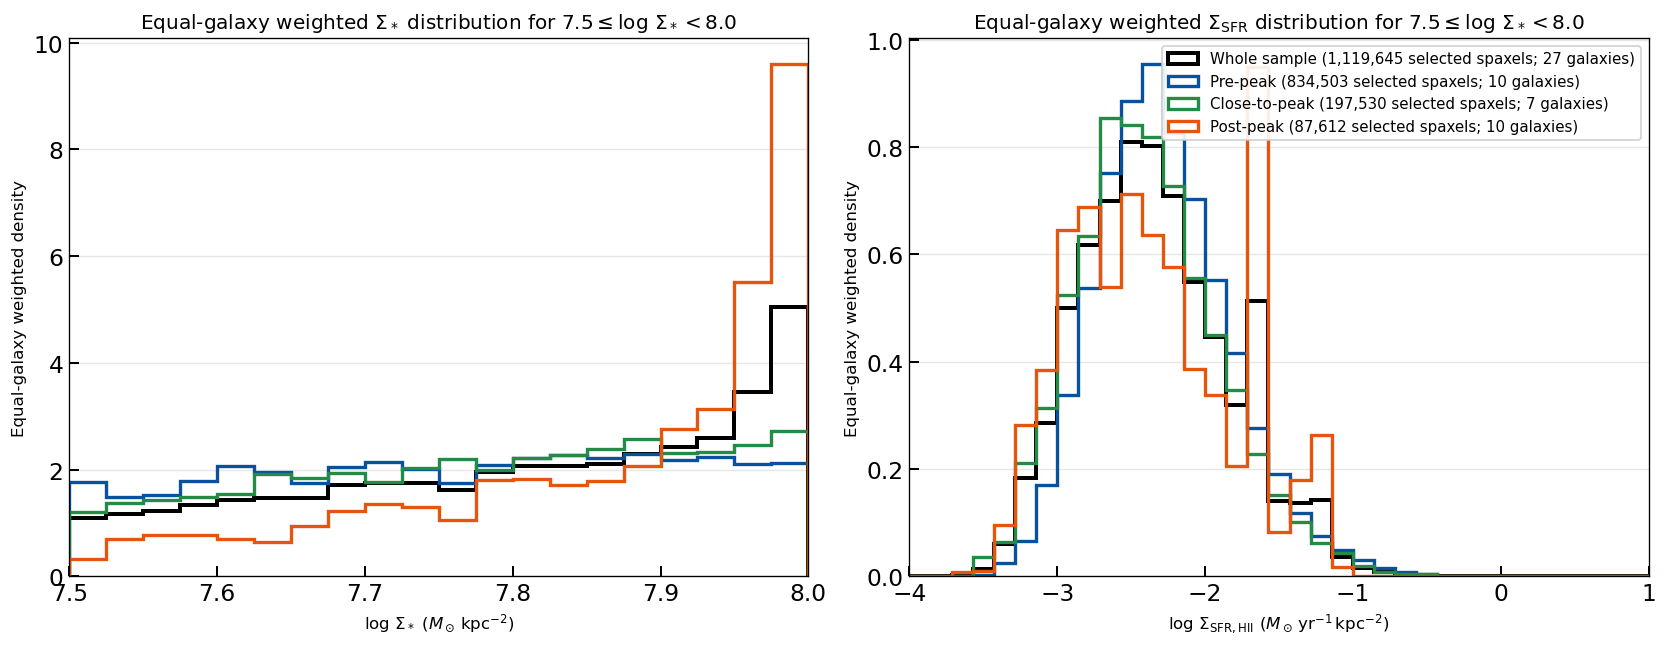

In [9]:
# Equal-galaxy weighted mass and SFR distributions for 7.5 <= log Sigma_* < 8.0.
MASS_RANGE = (7.5, 8.0)
MASS_RANGE_LABEL = r"$7.5 \leq \log\,\Sigma_* < 8.0$"
MASS_RANGE_BINS = 20

mass_range_edges = np.linspace(*MASS_RANGE, MASS_RANGE_BINS + 1)
sfr_range_edges = np.linspace(*RSFMS_YRANGE, HISTOGRAM_BINS + 1)

fig, (ax_mass, ax_sfr) = plt.subplots(1, 2, figsize=(14, 5.5))

samples = [("Whole sample", all_x_full, all_y_full, all_galaxy_full, HISTOGRAM_FULL_STYLE)]
for stage in (1, 2, 3):
    samples.append(
        (
            RSFMS_STAGE_LABELS[stage],
            stage_log_sigma_m[stage],
            stage_log_sigma_sfr[stage],
            stage_spaxel_galaxy[stage],
            {
                "color": RSFMS_STAGE_STYLE[stage]["contour"],
                "linewidth": 2.0,
                "linestyle": "-",
            },
        )
    )

for label, mass_values, sfr_values, galaxy_ids, style in samples:
    mass_values = np.asarray(mass_values, dtype=float)
    sfr_values = np.asarray(sfr_values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(mass_values) & np.isfinite(sfr_values)
    in_mass_range = (mass_values >= MASS_RANGE[0]) & (mass_values < MASS_RANGE[1])
    selected = finite & in_mass_range
    selected_mass = mass_values[selected]
    selected_sfr = sfr_values[selected]
    selected_galaxies = galaxy_ids[selected]
    if selected_mass.size == 0:
        print(f"{label}: no spaxels in {MASS_RANGE}")
        continue

    mass_plot, mass_weights, mass_galaxies = equal_galaxy_histogram_data(
        selected_mass, selected_galaxies, mass_range_edges
    )
    sfr_plot, sfr_weights, sfr_galaxies = equal_galaxy_histogram_data(
        selected_sfr, selected_galaxies, sfr_range_edges
    )
    legend_label = (
        f"{label} ({selected_mass.size:,} selected spaxels; "
        f"{np.unique(selected_galaxies).size} galaxies)"
    )
    ax_mass.hist(
        mass_plot,
        bins=mass_range_edges,
        weights=mass_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )
    ax_sfr.hist(
        sfr_plot,
        bins=sfr_range_edges,
        weights=sfr_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )

ax_mass.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=MASS_RANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distribution for " + MASS_RANGE_LABEL,
)
ax_sfr.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distribution for " + MASS_RANGE_LABEL,
)
for axis in (ax_mass, ax_sfr):
    axis.grid(True, axis="y", alpha=0.3)
ax_sfr.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


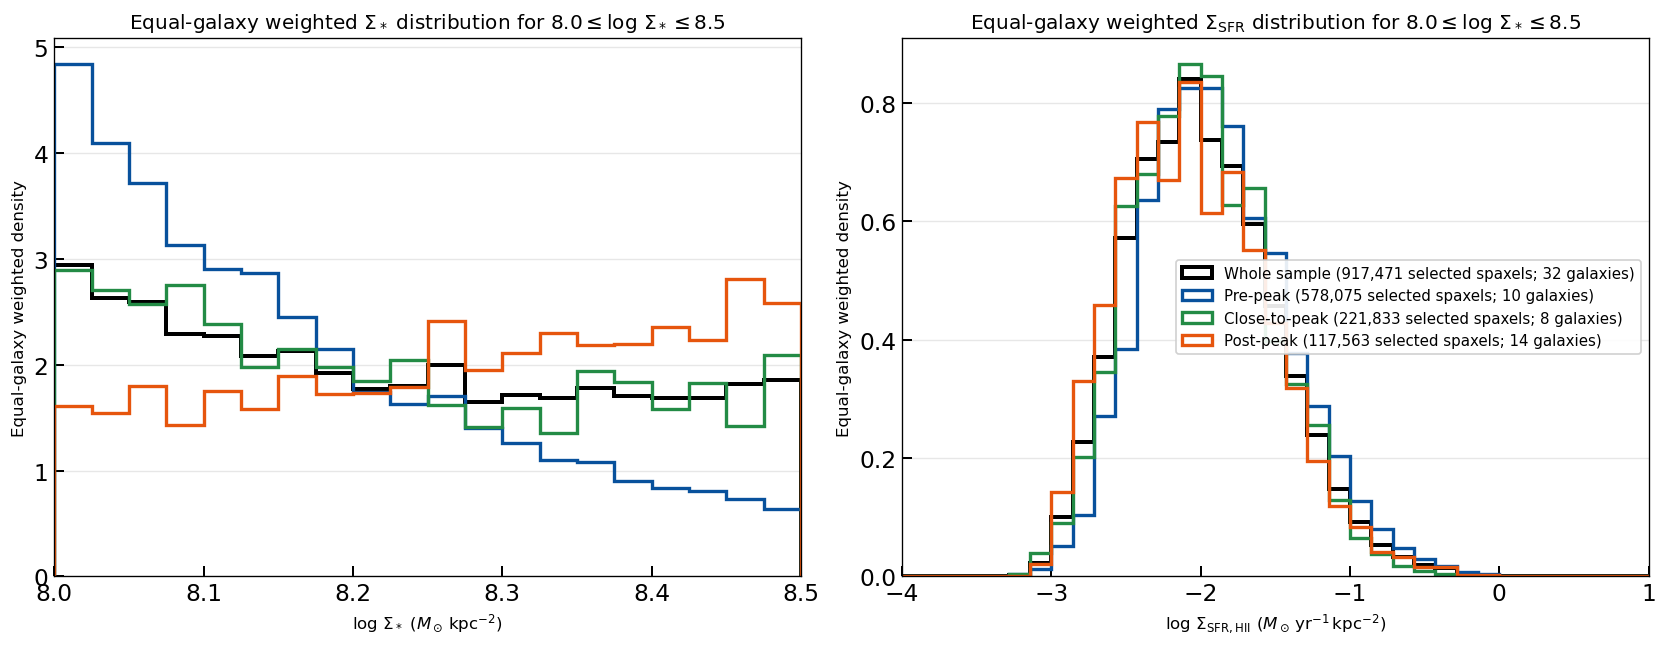

In [10]:
# Equal-galaxy weighted mass and SFR distributions for 8.0 <= log Sigma_* <= 8.5.
MASS_RANGE = (8.0, 8.5)
MASS_RANGE_LABEL = r"$8.0 \leq \log\,\Sigma_* \leq 8.5$"
MASS_RANGE_BINS = 20

mass_range_edges = np.linspace(*MASS_RANGE, MASS_RANGE_BINS + 1)
sfr_range_edges = np.linspace(*RSFMS_YRANGE, HISTOGRAM_BINS + 1)

fig, (ax_mass, ax_sfr) = plt.subplots(1, 2, figsize=(14, 5.5))

samples = [("Whole sample", all_x_full, all_y_full, all_galaxy_full, HISTOGRAM_FULL_STYLE)]
for stage in (1, 2, 3):
    samples.append(
        (
            RSFMS_STAGE_LABELS[stage],
            stage_log_sigma_m[stage],
            stage_log_sigma_sfr[stage],
            stage_spaxel_galaxy[stage],
            {
                "color": RSFMS_STAGE_STYLE[stage]["contour"],
                "linewidth": 2.0,
                "linestyle": "-",
            },
        )
    )

for label, mass_values, sfr_values, galaxy_ids, style in samples:
    mass_values = np.asarray(mass_values, dtype=float)
    sfr_values = np.asarray(sfr_values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(mass_values) & np.isfinite(sfr_values)
    in_mass_range = (mass_values >= MASS_RANGE[0]) & (mass_values <= MASS_RANGE[1])
    selected = finite & in_mass_range
    selected_mass = mass_values[selected]
    selected_sfr = sfr_values[selected]
    selected_galaxies = galaxy_ids[selected]
    if selected_mass.size == 0:
        print(f"{label}: no spaxels in {MASS_RANGE}")
        continue

    mass_plot, mass_weights, mass_galaxies = equal_galaxy_histogram_data(
        selected_mass, selected_galaxies, mass_range_edges
    )
    sfr_plot, sfr_weights, sfr_galaxies = equal_galaxy_histogram_data(
        selected_sfr, selected_galaxies, sfr_range_edges
    )
    legend_label = (
        f"{label} ({selected_mass.size:,} selected spaxels; "
        f"{np.unique(selected_galaxies).size} galaxies)"
    )
    ax_mass.hist(
        mass_plot,
        bins=mass_range_edges,
        weights=mass_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )
    ax_sfr.hist(
        sfr_plot,
        bins=sfr_range_edges,
        weights=sfr_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )

ax_mass.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=MASS_RANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distribution for " + MASS_RANGE_LABEL,
)
ax_sfr.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distribution for " + MASS_RANGE_LABEL,
)
for axis in (ax_mass, ax_sfr):
    axis.grid(True, axis="y", alpha=0.3)
ax_sfr.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


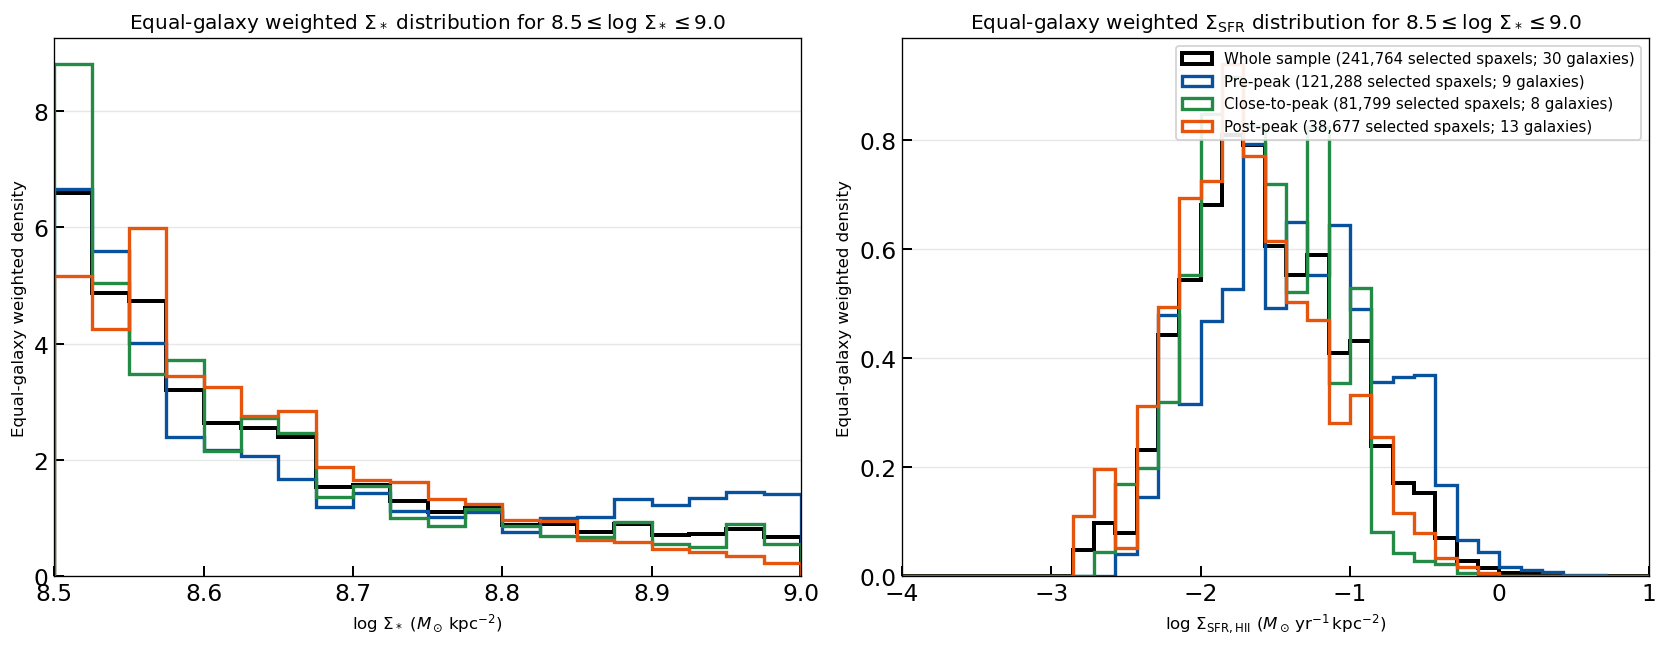

In [11]:
# Equal-galaxy weighted mass and SFR distributions for 8.5 <= log Sigma_* <= 9.0.
MASS_RANGE = (8.5, 9.0)
MASS_RANGE_LABEL = r"$8.5 \leq \log\,\Sigma_* \leq 9.0$"
MASS_RANGE_BINS = 20

mass_range_edges = np.linspace(*MASS_RANGE, MASS_RANGE_BINS + 1)
sfr_range_edges = np.linspace(*RSFMS_YRANGE, HISTOGRAM_BINS + 1)

fig, (ax_mass, ax_sfr) = plt.subplots(1, 2, figsize=(14, 5.5))

samples = [("Whole sample", all_x_full, all_y_full, all_galaxy_full, HISTOGRAM_FULL_STYLE)]
for stage in (1, 2, 3):
    samples.append(
        (
            RSFMS_STAGE_LABELS[stage],
            stage_log_sigma_m[stage],
            stage_log_sigma_sfr[stage],
            stage_spaxel_galaxy[stage],
            {
                "color": RSFMS_STAGE_STYLE[stage]["contour"],
                "linewidth": 2.0,
                "linestyle": "-",
            },
        )
    )

for label, mass_values, sfr_values, galaxy_ids, style in samples:
    mass_values = np.asarray(mass_values, dtype=float)
    sfr_values = np.asarray(sfr_values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(mass_values) & np.isfinite(sfr_values)
    in_mass_range = (mass_values >= MASS_RANGE[0]) & (mass_values <= MASS_RANGE[1])
    selected = finite & in_mass_range
    selected_mass = mass_values[selected]
    selected_sfr = sfr_values[selected]
    selected_galaxies = galaxy_ids[selected]
    if selected_mass.size == 0:
        print(f"{label}: no spaxels in {MASS_RANGE}")
        continue

    mass_plot, mass_weights, mass_galaxies = equal_galaxy_histogram_data(
        selected_mass, selected_galaxies, mass_range_edges
    )
    sfr_plot, sfr_weights, sfr_galaxies = equal_galaxy_histogram_data(
        selected_sfr, selected_galaxies, sfr_range_edges
    )
    legend_label = (
        f"{label} ({selected_mass.size:,} selected spaxels; "
        f"{np.unique(selected_galaxies).size} galaxies)"
    )
    ax_mass.hist(
        mass_plot,
        bins=mass_range_edges,
        weights=mass_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )
    ax_sfr.hist(
        sfr_plot,
        bins=sfr_range_edges,
        weights=sfr_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )

ax_mass.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=MASS_RANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distribution for " + MASS_RANGE_LABEL,
)
ax_sfr.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distribution for " + MASS_RANGE_LABEL,
)
for axis in (ax_mass, ax_sfr):
    axis.grid(True, axis="y", alpha=0.3)
ax_sfr.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


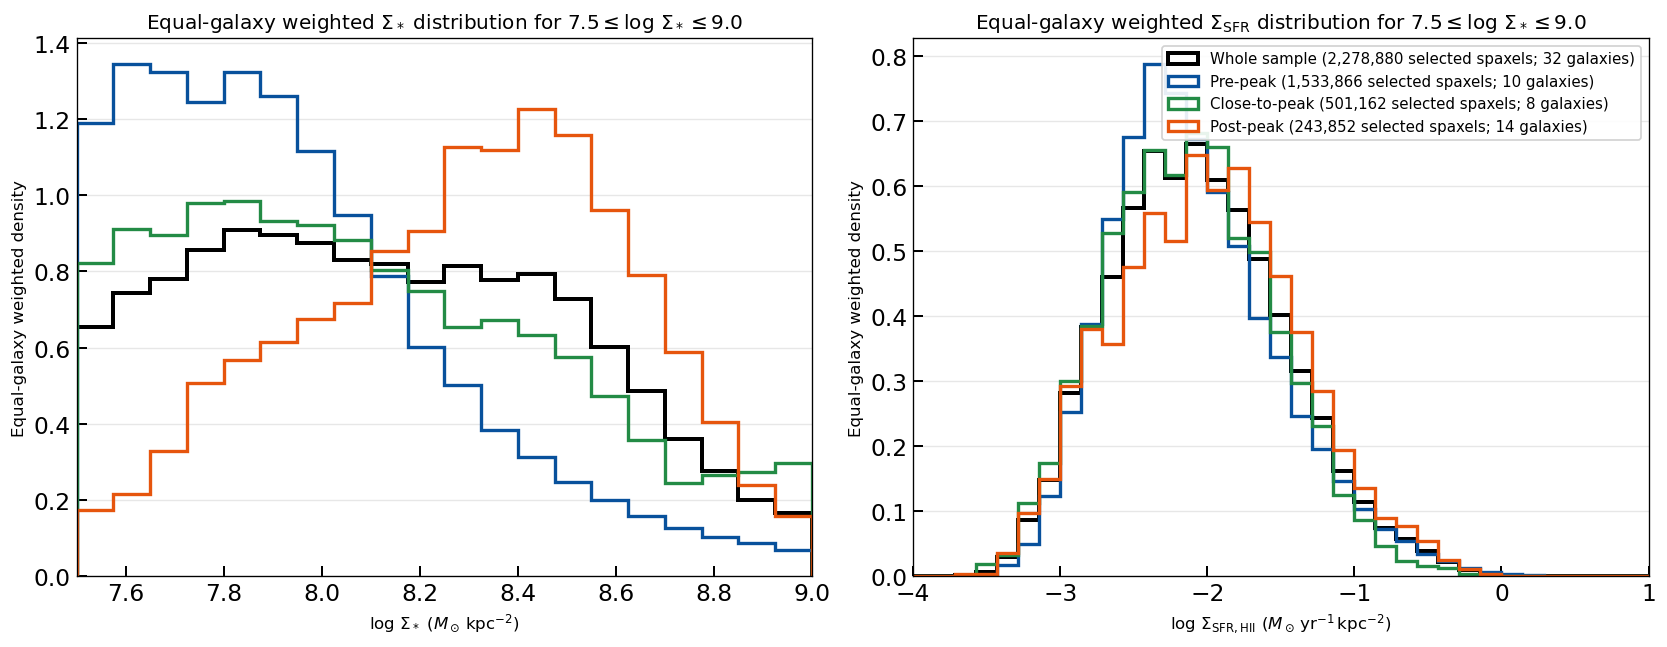

In [12]:
# Equal-galaxy weighted mass and SFR distributions for 7.5 <= log Sigma_* <= 9.0.
MASS_RANGE = (7.5, 9.0)
MASS_RANGE_LABEL = r"$7.5 \leq \log\,\Sigma_* \leq 9.0$"
MASS_RANGE_BINS = 20

mass_range_edges = np.linspace(*MASS_RANGE, MASS_RANGE_BINS + 1)
sfr_range_edges = np.linspace(*RSFMS_YRANGE, HISTOGRAM_BINS + 1)

fig, (ax_mass, ax_sfr) = plt.subplots(1, 2, figsize=(14, 5.5))

samples = [("Whole sample", all_x_full, all_y_full, all_galaxy_full, HISTOGRAM_FULL_STYLE)]
for stage in (1, 2, 3):
    samples.append(
        (
            RSFMS_STAGE_LABELS[stage],
            stage_log_sigma_m[stage],
            stage_log_sigma_sfr[stage],
            stage_spaxel_galaxy[stage],
            {
                "color": RSFMS_STAGE_STYLE[stage]["contour"],
                "linewidth": 2.0,
                "linestyle": "-",
            },
        )
    )

for label, mass_values, sfr_values, galaxy_ids, style in samples:
    mass_values = np.asarray(mass_values, dtype=float)
    sfr_values = np.asarray(sfr_values, dtype=float)
    galaxy_ids = np.asarray(galaxy_ids, dtype=str)
    finite = np.isfinite(mass_values) & np.isfinite(sfr_values)
    in_mass_range = (mass_values >= MASS_RANGE[0]) & (mass_values <= MASS_RANGE[1])
    selected = finite & in_mass_range
    selected_mass = mass_values[selected]
    selected_sfr = sfr_values[selected]
    selected_galaxies = galaxy_ids[selected]
    if selected_mass.size == 0:
        print(f"{label}: no spaxels in {MASS_RANGE}")
        continue

    mass_plot, mass_weights, mass_galaxies = equal_galaxy_histogram_data(
        selected_mass, selected_galaxies, mass_range_edges
    )
    sfr_plot, sfr_weights, sfr_galaxies = equal_galaxy_histogram_data(
        selected_sfr, selected_galaxies, sfr_range_edges
    )
    legend_label = (
        f"{label} ({selected_mass.size:,} selected spaxels; "
        f"{np.unique(selected_galaxies).size} galaxies)"
    )
    ax_mass.hist(
        mass_plot,
        bins=mass_range_edges,
        weights=mass_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )
    ax_sfr.hist(
        sfr_plot,
        bins=sfr_range_edges,
        weights=sfr_weights,
        density=True,
        histtype="step",
        label=legend_label,
        **style,
    )

ax_mass.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel="Equal-galaxy weighted density",
    xlim=MASS_RANGE,
    title=r"Equal-galaxy weighted $\Sigma_*$ distribution for " + MASS_RANGE_LABEL,
)
ax_sfr.set(
    xlabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    ylabel="Equal-galaxy weighted density",
    xlim=RSFMS_YRANGE,
    title=r"Equal-galaxy weighted $\Sigma_{\mathrm{SFR}}$ distribution for " + MASS_RANGE_LABEL,
)
for axis in (ax_mass, ax_sfr):
    axis.grid(True, axis="y", alpha=0.3)
ax_sfr.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.show()


,Infall stage,alpha,beta,N_spaxels,N_galaxies,RMSE,R_squared
0,Pre-peak,1.116,-10.954,"1,533,866",10,0.444,0.387
1,Close-to-peak,0.949,-9.794,"501,162",8,0.428,0.420
2,Post-peak,1.329,-13.013,"243,852",14,0.428,0.512


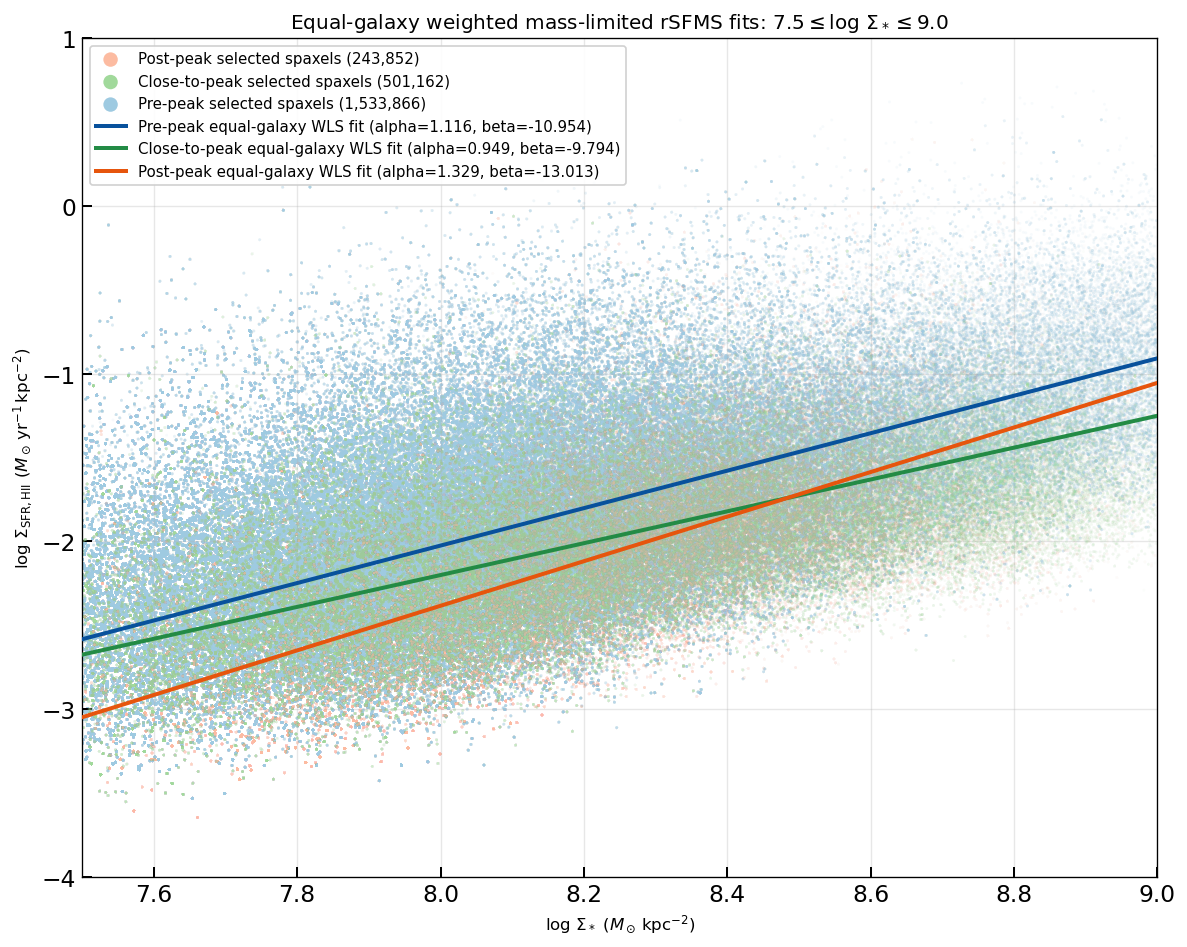

In [13]:
# Mass-limited rSFMS scatter and independent equal-galaxy weighted fits for the three infall stages.
MASS_LIMITED_RSFMS_RANGE = (7.5, 9.0)
MASS_LIMITED_FIT_COLORS = {
    1: "#08519C",
    2: "#238B45",
    3: "#E6550D",
}

mass_limited_stage_data = {}
mass_limited_fit_rows = []

for stage in (1, 2, 3):
    x = np.asarray(stage_log_sigma_m[stage], dtype=float)
    y = np.asarray(stage_log_sigma_sfr[stage], dtype=float)
    galaxy_ids = np.asarray(stage_spaxel_galaxy[stage], dtype=str)
    selected = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= MASS_LIMITED_RSFMS_RANGE[0])
        & (x <= MASS_LIMITED_RSFMS_RANGE[1])
    )
    x_selected = x[selected]
    y_selected = y[selected]
    galaxy_selected = galaxy_ids[selected]
    if x_selected.size < 2:
        raise RuntimeError(
            f"{RSFMS_STAGE_LABELS[stage]} has fewer than two selected spaxels"
        )

    fit = equal_galaxy_rsfms_fit(x_selected, y_selected, galaxy_selected)
    mass_limited_stage_data[stage] = (
        x_selected, y_selected, galaxy_selected, fit
    )
    mass_limited_fit_rows.append(
        {
            "Infall stage": RSFMS_STAGE_LABELS[stage],
            "alpha": fit["alpha"],
            "beta": fit["beta"],
            "N_spaxels": fit["n_spaxels"],
            "N_galaxies": fit["n_galaxies"],
            "RMSE": fit["rmse"],
            "R_squared": fit["r_squared"],
        }
    )

mass_limited_fit_results = pd.DataFrame(mass_limited_fit_rows)
display(
    mass_limited_fit_results.style.format(
        {
            "alpha": "{:.3f}",
            "beta": "{:.3f}",
            "N_spaxels": "{:,}",
            "N_galaxies": "{:,}",
            "RMSE": "{:.3f}",
            "R_squared": "{:.3f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

# Show only the selected spaxels and their stage-specific weighted fits.
for stage in (3, 2, 1):
    x_selected, y_selected, galaxy_selected, fit = mass_limited_stage_data[stage]
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x_selected,
        y_selected,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=(
            f"{RSFMS_STAGE_LABELS[stage]} selected spaxels "
            f"({x_selected.size:,})"
        ),
    )

fit_x = np.linspace(*MASS_LIMITED_RSFMS_RANGE, 200)
for stage in (1, 2, 3):
    _, _, _, fit = mass_limited_stage_data[stage]
    ax.plot(
        fit_x,
        fit["alpha"] * fit_x + fit["beta"],
        color=MASS_LIMITED_FIT_COLORS[stage],
        linewidth=2.4,
        zorder=10 + stage,
        label=(
            f"{RSFMS_STAGE_LABELS[stage]} equal-galaxy WLS fit "
            f"(alpha={fit['alpha']:.3f}, beta={fit['beta']:.3f})"
        ),
    )

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=MASS_LIMITED_RSFMS_RANGE,
    ylim=RSFMS_YRANGE,
    title=(
        r"Equal-galaxy weighted mass-limited rSFMS fits: "
        r"$7.5 \leq \log\,\Sigma_* \leq 9.0$"
    ),
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="upper left", fontsize=9, framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
plt.show()
